In [1]:
%load_ext autoreload
%autoreload 2


%run ../src/run.py --help


usage: run.py [-h] [--seed SEED] --experiment
              {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
              --approach
              {random,sgd,sgd-frozen,lwf,lfl,ewc,imm-mean,progressive,pathnet,imm-mode,sgd-restart,ewc2,ewc-film,joint,hat,hat-test,gvcl,vcl,vclf,gvclf}
              [--output OUTPUT] [--nepochs NEPOCHS] [--lr LR]
              [--parameter PARAMETER] [--ntasks NTASKS]
              [--use-best-hyperparams USE_BEST_HYPERPARAMS]

xxx

options:
  -h, --help            show this help message and exit
  --seed SEED           (default=0)
  --experiment {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
                        (default=)
  --approach {random,sgd,sgd-frozen,lwf,lfl,ewc,imm-mean,progressive,pathnet,imm-mode,sgd-restart,ewc2,ewc-film,joint,hat,hat-test,gvcl,vcl,vclf,gvclf}
                        (default=)
  --output OUTPUT       (default=)
  --nepochs NEPOCHS     (default=-1)
  --lr LR               (default=-1.000000)
  --pa

In [2]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
%run ../src/dataloaders/hasy_utils.py

Note that currently gvcl is actually implementing renyi regularization

In [9]:
%run ../src/run.py --experiment cifar --approach gvcl --seed 3

Arguments =
	seed: 3
	experiment: cifar
	approach: gvcl
	output: ../res/cifar_gvcl_3.txt
	nepochs: -1
	lr: -1
	parameter: 
	ntasks: -1
	use_best_hyperparams: True
approach VCL True
Load data...
Task order = [0, 1, 2, 3, 4, 5]
Input size = [3, 32, 32] 
Task info = [(0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]
Inits...
Film type point
----------------------------------------------------------------------------------------------------
Net(
  (conv_layers): ModuleList(
    (0): MFConvLayer(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MFConvLayer(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MFConvLayer(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MFConvLayer(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_layers): ModuleList(
    (0): MFLinearLayer()
  )
  (heads): ModuleList(
    (0-5): 6 x MFLinearLayer()
  )
  (conv_film_layers): ModuleList(
    (0-3): 4 x PointFiLMLayer()
  )
  (fc_film_lay

: 

In [ ]:
%run ../src/run.py --experiment smnist --approach gvclf --seed 3

In [ ]:
import math

def compute_renyi(alpha, mu0, sigma0, mu1, sigma1):
    """
    Compute the Rényi divergence D_alpha between two normal distributions:
    N(mu0, sigma0^2) and N(mu1, sigma1^2).
    
    Parameters:
    - alpha: The Rényi divergence parameter (alpha > 0, alpha != 1).
    - mu0: Mean of the first distribution.
    - sigma0: Standard deviation of the first distribution.
    - mu1: Mean of the second distribution.
    - sigma1: Standard deviation of the second distribution.
    
    Returns:
    - D_alpha: The Rényi divergence value.
    """
    # Compute sigma^2_alpha
    sigma_alpha_squared = (1 - alpha) * sigma0**2 + alpha * sigma1**2
    if sigma_alpha_squared <= 0:
        raise ValueError("sigma_alpha_squared must be greater than 0.")
    
    # Compute terms of the Rényi divergence
    mean_term = alpha * (mu1 - mu0)**2 / (2 * sigma_alpha_squared)
    log_term = (1 / (1 - alpha)) * math.log(
        (sigma_alpha_squared ** 0.5) / (sigma0 ** (1 - alpha) * sigma1 ** alpha)
    )
    
    # Calculate the Rényi divergence
    D_alpha = mean_term + log_term
    return D_alpha

# Example usage:
alpha = 2.0
mu0 = 0.0
sigma0 = 1.0
mu1 = 1.0
sigma1 = 2.0

result = compute_renyi(alpha, mu0, sigma0, mu1, sigma1)
print(f"Rényi divergence: {result}")


In [6]:
import torch

def renyi_divergence_univariate_gaussians(mean, log_var, prior_mean, log_prior_var, alpha, sum = True):
    """
    Compute the Rényi divergence between univariate Gaussian posterior and prior distributions.
    
    Args:
        mean (torch.Tensor): Posterior mean (shape: [n]).
        log_var (torch.Tensor): Log-variance of the posterior (shape: [n]).
        prior_mean (torch.Tensor): Prior mean (shape: [n]).
        log_prior_var (torch.Tensor): Log-variance of the prior (shape: [n]).
        alpha (float): Order of the Rényi divergence (alpha > 0, alpha != 1).
    
    Returns:
        torch.Tensor: Rényi divergence for each element in the input tensor (shape: [n]).
    """
    # Compute posterior variance and prior variance from log-variances
    var = torch.exp(log_var)  # Posterior variance
    prior_var = torch.exp(log_prior_var)  # Prior variance

    # Compute the mixed variance (Σ_α)^*
    mixed_var = alpha * prior_var + (1 - alpha) * var

    # Compute the Mahalanobis term: α (μ - μ_prior)^2 / (Σ_α)^*
    mahalanobis_term = alpha * (mean - prior_mean) ** 2 / mixed_var

    # Compute the determinant term: log(|Σ_α^*|) - ((1 - α) log(|Σ|) + α log(|Σ_prior|))
    log_det_term = torch.log(mixed_var) - ((1 - alpha) * log_var + alpha * log_prior_var)

    if sum:
        return 0.5 * torch.sum(mahalanobis_term - 0.5 / (alpha - 1) * log_det_term)
    # Combine terms to compute Rényi divergence
    else:
        return 0.5 * mahalanobis_term - 0.5 / (alpha - 1)

# Example data
mean = torch.tensor([0.5, 0.2, -0.3])
log_var = torch.tensor([-1.0, -0.5, -1.2])
prior_mean = torch.tensor([0.0, 0.0, 0.0])
log_prior_var = torch.tensor([-0.5, -0.5, -0.5])
alpha = 0.5

# Compute Rényi divergence
divergence = renyi_divergence_univariate_gaussians(mean, log_var, prior_mean, log_prior_var, alpha)
print(divergence)



tensor(0.2398)


In [ ]:
%run ../src/run.py --experiment easy-chasy --approach hat --seed 0

In [ ]:
%run ../src/run.py --experiment cifar --approach hat

In [1]:
%run ../src/run.py --experiment cifar --approach gvclf --seed 3

Arguments =
	seed: 3
	experiment: cifar
	approach: gvclf
	output: ../res/cifar_gvclf_3.txt
	nepochs: -1
	lr: -1
	parameter: 
	ntasks: -1
	use_best_hyperparams: True
approach VCL True
Load data...
Task order = [0, 1, 2, 3, 4, 5]


/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/dataloaders/cifar.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data[i][s]['x']=torch.load(os.path.join(os.path.ex

Input size = [3, 32, 32] 
Task info = [(0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]
Inits...
Film type scale
----------------------------------------------------------------------------------------------------
Net(
  (conv_layers): ModuleList(
    (0): MFConvLayer(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MFConvLayer(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MFConvLayer(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MFConvLayer(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_layers): ModuleList(
    (0): MFLinearLayer()
  )
  (heads): ModuleList(
    (0-5): 6 x MFLinearLayer()
  )
  (conv_film_layers): ModuleList(
    (0-3): 4 x PointFiLMLayer()
  )
  (fc_film_layers): ModuleList(
    (0): PointFiLMLayer()
  )
)
Dimensions = torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 3, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.Size([32]) torch.Size([32, 32, 3, 3]) torch.

/home/nelosegui/BIFOLD_work/CL_curved/gvcl_fork/src/approaches/gvcl.py:144: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(self.model.parameters(),self.clipgrad)


| Epoch   1, time= 55.9ms| Train: class_loss=0.023  kl_loss=0.180 total_loss=0.203, acc= 48.6% |
| Epoch   2, time= 55.4ms| Train: class_loss=0.014  kl_loss=0.155 total_loss=0.169, acc= 69.3% |
| Epoch   3, time= 55.4ms| Train: class_loss=0.011  kl_loss=0.130 total_loss=0.141, acc= 78.2% |
| Epoch   4, time= 55.4ms| Train: class_loss=0.008  kl_loss=0.107 total_loss=0.116, acc= 84.0% |
| Epoch   5, time= 55.4ms| Train: class_loss=0.007  kl_loss=0.086 total_loss=0.093, acc= 88.5% |
| Epoch   6, time= 55.4ms| Train: class_loss=0.006  kl_loss=0.068 total_loss=0.074, acc= 91.2% |
| Epoch   7, time= 55.4ms| Train: class_loss=0.006  kl_loss=0.054 total_loss=0.059, acc= 92.7% |
| Epoch   8, time= 55.4ms| Train: class_loss=0.006  kl_loss=0.042 total_loss=0.047, acc= 93.5% |
| Epoch   9, time= 55.4ms| Train: class_loss=0.005  kl_loss=0.034 total_loss=0.039, acc= 94.1% |
| Epoch  10, time= 55.4ms| Train: class_loss=0.005  kl_loss=0.028 total_loss=0.033, acc= 94.7% |
| Epoch  11, time= 55.5ms| Tra

In [ ]:
import torch
print(torch.cuda.is_available())

In [ ]:
%run ../src/run.py --experiment cifar --approach gvclf

In [ ]:
%run ../src/run.py --experiment smnist --approach hat --seed 14

In [ ]:
import matplotlib.pyplot as plt

def calculate_average_accuracy(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    average_accuracies = []
    
    for i, line in enumerate(lines):
        values = list(map(float, line.split()))
        non_zero_values = values[:i+1]
        average_accuracy = sum(non_zero_values) / len(non_zero_values)
        average_accuracies.append(average_accuracy)
        print(f"Row {i+1} average accuracy: {average_accuracy:.4f}")
    
    return average_accuracies

def plot_accuracies(accuracies):
    plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o')
    plt.xlabel('Number of Tasks Learned')
    plt.ylabel('Average Accuracy')
    plt.title('Average Accuracy Across Tasks')
    plt.grid(True)
    plt.show()

# Calculate average accuracies
average_accuracies = calculate_average_accuracy('../res/smnist_gvclf_14.txt')

# Plot the accuracies
plot_accuracies(average_accuracies)

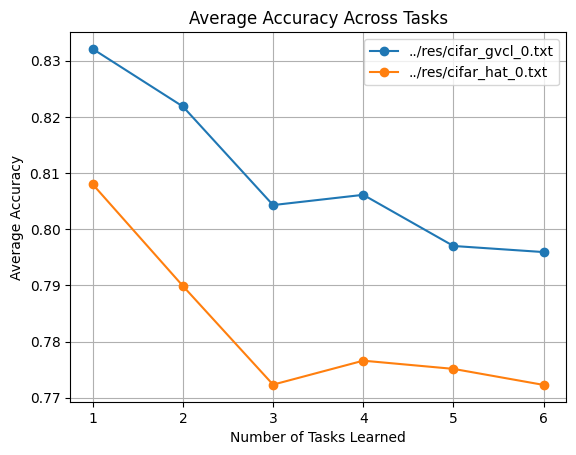

In [ ]:
import matplotlib.pyplot as plt

def calculate_average_accuracy(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    average_accuracies = []
    
    for i, line in enumerate(lines):
        values = list(map(float, line.split()))
        non_zero_values = values[:i+1]
        average_accuracy = sum(non_zero_values) / len(non_zero_values)
        average_accuracies.append(average_accuracy)
        #print(f"Row {i+1} average accuracy: {average_accuracy:.4f}")
    
    return average_accuracies

def plot_accuracies(file_paths):
    for file_path in file_paths:
        accuracies = calculate_average_accuracy(file_path)
        plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', label=file_path)
    
    plt.xlabel('Number of Tasks Learned')
    plt.ylabel('Average Accuracy')
    plt.title('Average Accuracy Across Tasks')
    plt.legend()
    plt.grid(True)
    plt.show()

# List of result files
result_files = [
    '../res/smnist_gvcl_0.txt',
    '../res/smnist_hat_0.txt',
    '../res/smnist_vcrenyi_3.txt',
]

# Plot the accuracies for each result file
plot_accuracies(result_files)